# Control of thin adaptive optics (TAO) gclib in Ophyd

Date: July 2nd 2026 

Authors: Henry (khchan@lbl.gov) Wei "Francis" He (francisho@lbl.gov)
___

## Overview

Testing the control of TAO using gclib

# SETUP 

In [1]:
import numpy as np
import monoplus as mp
import wfs_live as wfl


## Connect the device

In [2]:
import gclib
from ophyd import Device, Component as Cpt, Signal
from ophyd.status import DeviceStatus
from bluesky import RunEngine
import bluesky.plans as bp
from ophyd.sim import det


class GalilVoltageMotor(Device):
    # The component that will hold our current voltage reading for Bluesky
    readback = Cpt(Signal, value=0.0, kind='hinted', metadata={'units': 'V'})

    def __init__(self, connection, channel, prefix="", *, name, **kwargs):
        self.galil = connection
        self.channel = channel
        super().__init__(prefix=prefix, name=name, **kwargs)

    def set(self, target_voltage):
        # Create a status object that Bluesky uses to track motion
        status = DeviceStatus(self)

        # Enforce the 0V to 5V safety limits
        if target_voltage < 0.0 or target_voltage > 10.0:
            status.set_exception(
                ValueError(f"Voltage {target_voltage}V is outside the 0V to 10V limit.")
            )
            return status

        try:
            # Send the voltage change command to the controller
            self.galil.GCommand(f'AO {self.channel},{target_voltage}')

            # Read the actual hardware state back to confirm
            response = self.galil.GCommand(f'MG @AO[{self.channel}]')
            try:
                actual_voltage = float(response.strip())
            except ValueError:
                actual_voltage = target_voltage

            # Update the readback signal and tell Bluesky the move is complete
            self.readback.put(actual_voltage)
            status.set_finished()
        except Exception as exc:
            status.set_exception(exc)

        return status

    def trigger(self):
        """
        Called by Bluesky before a data point is read. This is where
        hardware I/O to refresh the value should happen — NOT in read().
        """
        status = DeviceStatus(self)
        try:
            response = self.galil.GCommand(f'MG @AO[{self.channel}]')
            try:
                actual_voltage = float(response.strip())
                self.readback.put(actual_voltage)
            except ValueError:
                pass
            status.set_finished()
        except Exception as exc:
            status.set_exception(exc)
        return status

    # No need to override read() — Device.read() will report the
    # last value stored in `readback` cheaply, without doing I/O.


# Establish the connection
connection = gclib.py()
connection.GOpen('192.168.10.123')

# Instantiate the custom motor device
voltage_motor_AO0 = GalilVoltageMotor(connection=connection, channel=0, name='galil_voltage_AO0')
voltage_motor_AO1 = GalilVoltageMotor(connection=connection, channel=1, name='galil_voltage_AO1')
voltage_motor_AO2 = GalilVoltageMotor(connection=connection, channel=2, name='galil_voltage_AO2')
voltage_motor_AO3 = GalilVoltageMotor(connection=connection, channel=3, name='galil_voltage_AO3')
voltage_motor_AO4 = GalilVoltageMotor(connection=connection, channel=4, name='galil_voltage_AO4')
voltage_motor_AO5 = GalilVoltageMotor(connection=connection, channel=5, name='galil_voltage_AO5')
voltage_motor_AO6 = GalilVoltageMotor(connection=connection, channel=6, name='galil_voltage_AO6')
voltage_motor_AO7 = GalilVoltageMotor(connection=connection, channel=7, name='galil_voltage_AO7')

# Example usage:
# RE = RunEngine({})
# RE(bp.count([voltage_motor], num=5))
# RE(bp.scan([det], voltage_motor, 0, 5, 11))

In [3]:
voltage_motor_AO0.set(0)
voltage_motor_AO1.set(0)
voltage_motor_AO2.set(0)
voltage_motor_AO3.set(0)
voltage_motor_AO4.set(0)
voltage_motor_AO5.set(0)
voltage_motor_AO6.set(0)
voltage_motor_AO7.set(0)
# RE = RunEngine({})

DeviceStatus(device=galil_voltage_AO7, done=True, success=True)

In [81]:
voltage_motor_AO7.set(00)

DeviceStatus(device=galil_voltage_AO7, done=True, success=True)

Status: 
- AO0: Working
- AO1: Sad
- AO2: Working
- AO3: Working
- AO4: Working
- AO5: Working
- AO6: Working, far
- AO7: Working, further

In [4]:
from ophyd import EpicsMotor
Obender = EpicsMotor('bl531_esp300:m101_bend_um', name='bender_um')
Obender.low_limit_travel.set(-2000)
Opitch = EpicsMotor('bl531_esp300:m101_pitch_mm', name='pitch_mm')
Opitch.low_limit_travel.set(-0.8)
Opitch.high_limit_travel.set(0.2)

Status(obj=EpicsSignal(read_pv='bl531_esp300:m101_pitch_mm.HLM', name='pitch_mm_high_limit_travel', parent='pitch_mm', timestamp=1783032204.401748, auto_monitor=True, string=False, write_pv='bl531_esp300:m101_pitch_mm.HLM', limits=False, put_complete=False), done=False, success=False)

In [5]:
print(Obender.get())
print(Opitch.get())

EpicsMotorTuple(user_readback=-800.01486, user_setpoint=-800.0, user_offset=0.0, user_offset_dir=0, offset_freeze_switch=0, set_use_switch=0, velocity=100.0, acceleration=0.2, motor_egu='um', motor_is_moving=0, motor_done_move=1, high_limit_switch=0, low_limit_switch=0, high_limit_travel=5000.0, low_limit_travel=-2000.0, direction_of_travel=1, motor_stop=0, home_forward=0, home_reverse=0)
EpicsMotorTuple(user_readback=0.149982, user_setpoint=0.15, user_offset=0.0, user_offset_dir=0, offset_freeze_switch=0, set_use_switch=0, velocity=0.1, acceleration=1.0, motor_egu='mm', motor_is_moving=0, motor_done_move=1, high_limit_switch=0, low_limit_switch=0, high_limit_travel=0.2, low_limit_travel=-0.8, direction_of_travel=1, motor_stop=0, home_forward=0, home_reverse=0)


In [6]:
# Physical Parameters (Experimental Setup)

z_gd_m = 0.3

camera_pixel_m = 2.4e-6      # Camera pixel size [m]
magnification = 5          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 8000               # Photon energy [eV]
wavelength_m = 1.23984e-6 / energy_eV

# Grating
grating_pitch_m = 6.2e-6      # Shearing grating pitch [m]

# Data dimensions
Nx = 3648                     # Number of pixels in 1D profile
x_m = np.arange(Nx) * dx_m   # Spatial axis [m]

print(f"Experimental Parameters:")
print(f"{'='*60}")
print(f"Wavelength: {wavelength_m*1e9:.3f} nm ({energy_eV} eV)")
print(f"Effective pixel size: {dx_m*1e6:.3f} μm")
print(f"Grating pitch: {grating_pitch_m*1e6:.1f} μm")
print(f"Spatial extent: {x_m[-1]*1e3:.2f} mm")

Experimental Parameters:
Wavelength: 0.155 nm (8000 eV)
Effective pixel size: 0.480 μm
Grating pitch: 6.2 μm
Spatial extent: 1.75 mm


In [7]:
%run -i /home/bl531/python/bluesky-web/queue-server/startup_bl531/00_base.py
%run -i /home/bl531/python/bluesky-web/queue-server/startup_bl531/01_motors.py
%run -i /home/bl531/python/bluesky-web/queue-server/startup_bl531/02_area_detectors.py
%run -i /home/bl531/python/bluesky-web/queue-server/startup_bl531/03_fluorescent_detectors.py
%run -i /home/bl531/python/bluesky-web/queue-server/startup_bl531/15_plans.py
%run -i /home/bl531/python/bluesky-web/queue-server/startup_bl531/16_plans_gisaxs.py
%run -i /home/bl531/python/bluesky-web/queue-server/startup_bl531/17_plans_XAS.py

Exposure time → 1 s
ROI set → channels [1800, 2750)  (950 channels)
0.0
(8192,)
OrderedDict({'amptek_fluo_roi_sum': {'value': 0.0, 'timestamp': 1783032211.4225862}})
{'fields': ['amptek_fluo_roi_sum']}
cannot connect to dxpMercury:PresetMode
Loading file '/home/bl531/python/bluesky-web/queue-server/startup_bl531/15_plans.py'
Loading file '/home/bl531/python/bluesky-web/queue-server/startup_bl531/17_plans_XAS.py'


In [8]:
import sys
sys.path.append('/home/bl531/python/nabla/')
from nabla.nophyd import MonoEnergy, BaslerDetector, BCSMotor

BASLER_FILES_ROOT = "/mnt/data531"
BASLER_5472_IMAGE_DIR = "scans/%Y/%m/%d/basler5472"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs

try:
    basler_5472 = BaslerDetector(
        "BL531acA5427:",
        name="basler_5472",
        image_dir=BASLER_5472_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_5472.cam.stage_sigs['image_mode']    = 'Single'
    basler_5472.cam.stage_sigs['num_images']    = 1
    basler_5472.cam.stage_sigs['acquire_time']  = 1 
    basler_5472.cam.stage_sigs['acquire_period'] = 0.5

    basler_5472.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    basler_5472.tiff.stage_sigs['enable']        = 1
    basler_5472.tiff.stage_sigs['auto_save']     = 'Yes'
    basler_5472.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    basler_5472.read_attrs      = ['tiff']
    basler_5472.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'")


Basler camera connected successfully.


# SCAN

## Tests

In [70]:
Obender.get()

EpicsMotorTuple(user_readback=-600.0135300000001, user_setpoint=-600.0, user_offset=0.0, user_offset_dir=0, offset_freeze_switch=0, set_use_switch=0, velocity=100.0, acceleration=0.2, motor_egu='um', motor_is_moving=0, motor_done_move=1, high_limit_switch=0, low_limit_switch=0, high_limit_travel=5000.0, low_limit_travel=-2000.0, direction_of_travel=1, motor_stop=0, home_forward=0, home_reverse=0)

In [71]:
Obender.move(-800)

MoveStatus(done=True, pos=bender_um, elapsed=4.4, success=True, settle_time=0.0)

In [75]:
from PIL import Image

# Load TIFF Image
filename = "Image__2026-07-02__1s.tiff"
im = Image.open(f'{filename}')
width, height = im.size

print(f"Loaded: {filename}")
print(f"Image dimensions: {width} × {height} pixels")


Loaded: Image__2026-07-02__1s.tiff
Image dimensions: 1200 × 3672 pixels


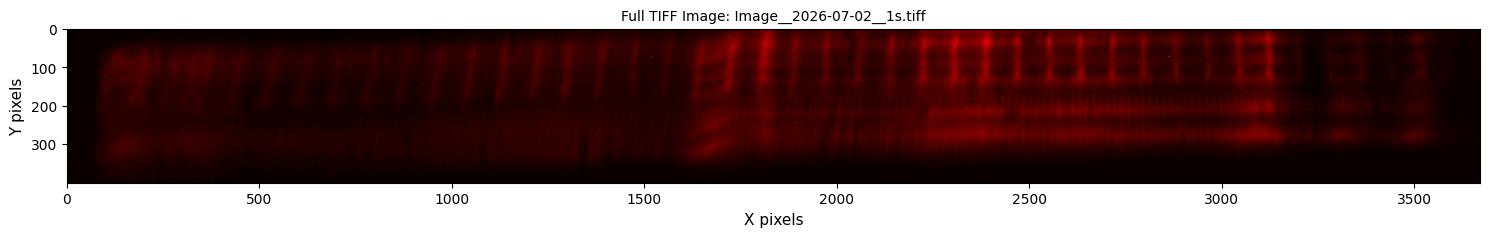

In [76]:

# Visualize full image
plt.figure(figsize=(15, 5))
plt.imshow(np.array(im).T[400:800], cmap='hot', interpolation='nearest')
plt.title(f'Full TIFF Image: {filename}', fontsize=10)
plt.xlabel('X pixels', fontsize=11)
plt.ylabel('Y pixels', fontsize=11)
# plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

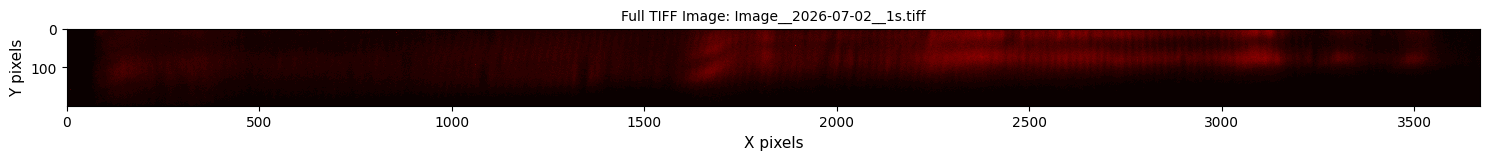

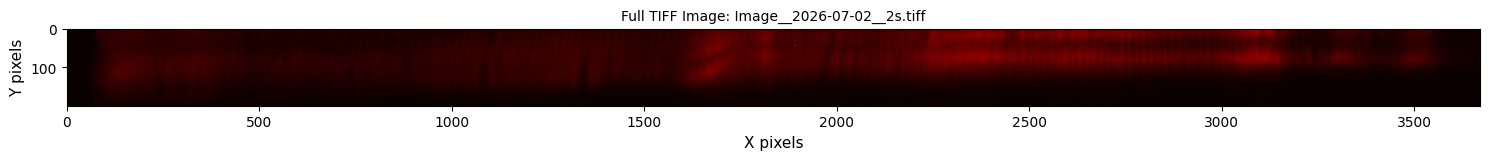

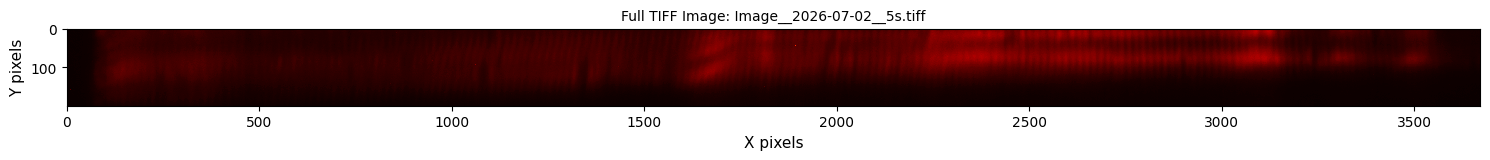

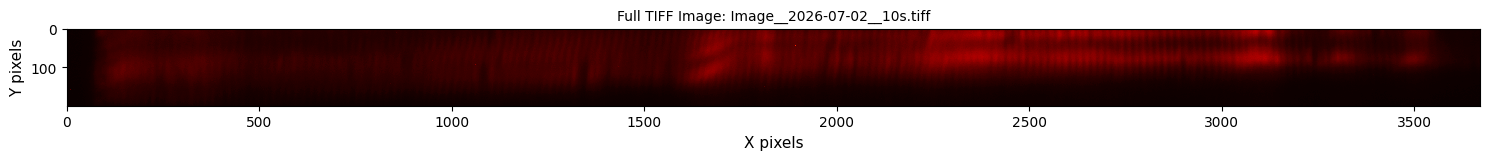

In [81]:
from PIL import Image

# List of exposure times to process
exposure_times = ["1s", "2s", "5s", "10s"]

images = {}

for exp_time in exposure_times:
    # Load TIFF Image
    filename = f"Image__2026-07-02__{exp_time}.tiff"
    im = Image.open(f'{filename}')
    width, height = im.size

    # print(f"Loaded: {filename}")
    # print(f"Image dimensions: {width} × {height} pixels")

    # Store image array in dict
    images[exp_time] = np.array(im)

    # Visualize full image
    plt.figure(figsize=(15, 5))
    plt.imshow(images[exp_time].T[600:800], cmap='hot', interpolation='nearest')
    plt.title(f'Full TIFF Image: {filename}', fontsize=10)
    plt.xlabel('X pixels', fontsize=11)
    plt.ylabel('Y pixels', fontsize=11)
    # plt.colorbar(label='Intensity [counts]')
    plt.tight_layout()
    plt.show()

[  ok]  λ=0.15nm  k_peak=112.3 cyc/mm  r_DC=60.0  SNR=23.4  f_pred=-0.96m  RMS_W=124.6nm  RMS_resid=1.759nm


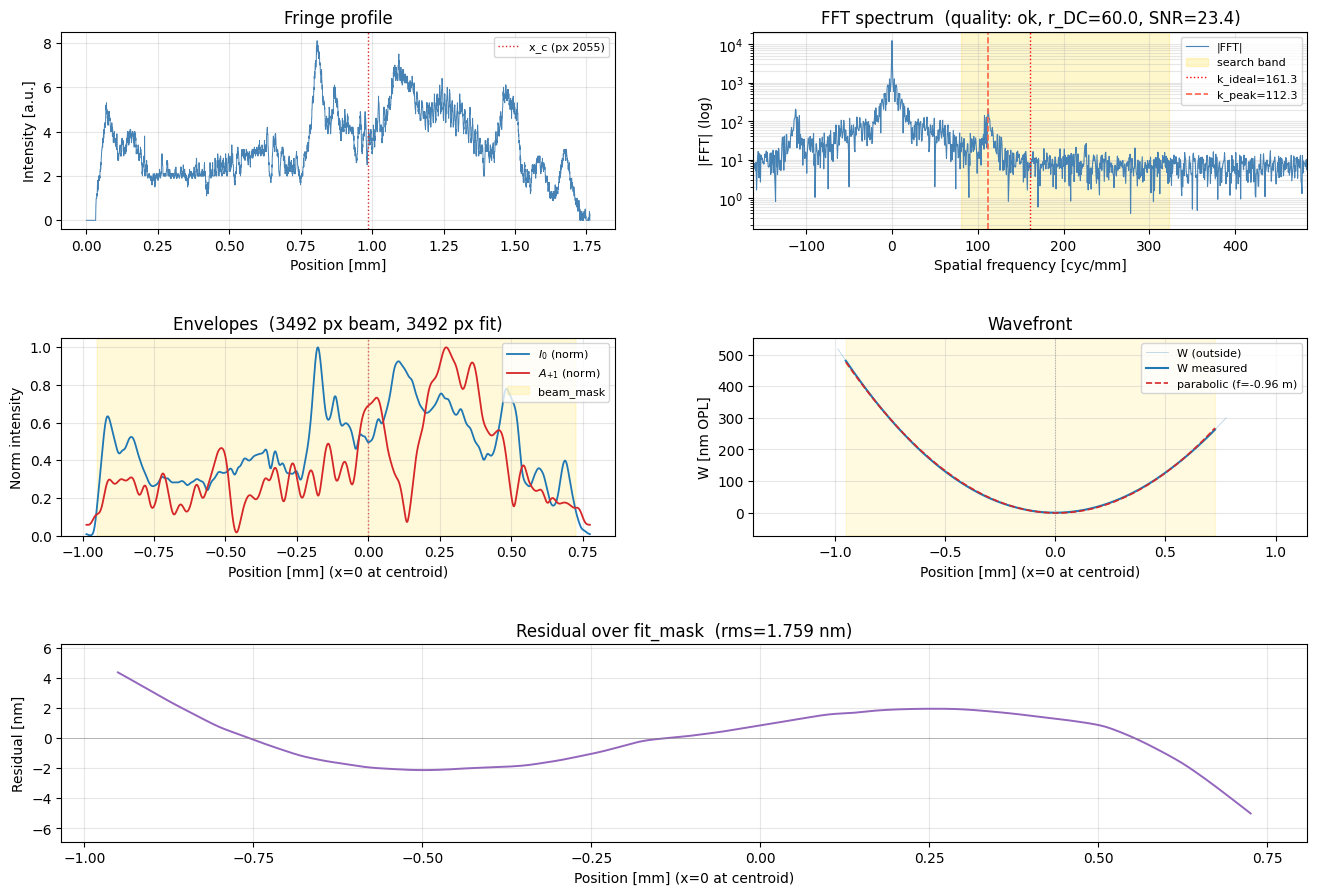

In [86]:
y_roi = slice(640+50, 650+50)

_ = wfl.quick_look(
    images['1s'][:], dx_m, grating_pitch_m, wavelength_m, z_gd_m, band_factor=2.0,
    y_roi=y_roi, axis=1, propagate=False, V_threshold=0
)

Exposure time: 1s
[good]  λ=0.15nm  k_peak=112.4 cyc/mm  r_DC=39.2  SNR=16.6  f_pred=-1.01m  RMS_W=32.3nm  RMS_resid=0.407nm


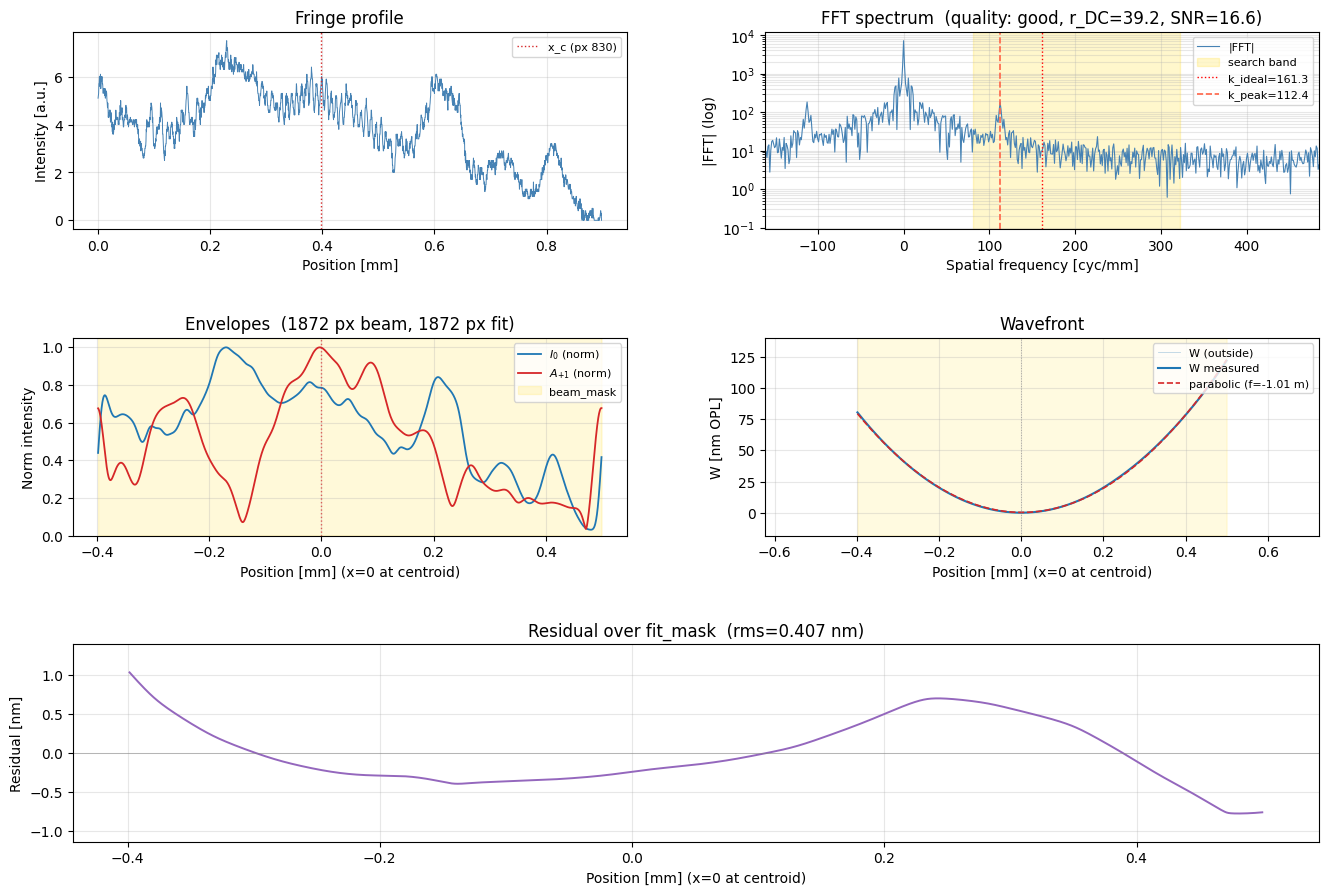

Exposure time: 2s
[good]  λ=0.15nm  k_peak=112.4 cyc/mm  r_DC=45.2  SNR=17.7  f_pred=-1.01m  RMS_W=32.0nm  RMS_resid=0.402nm


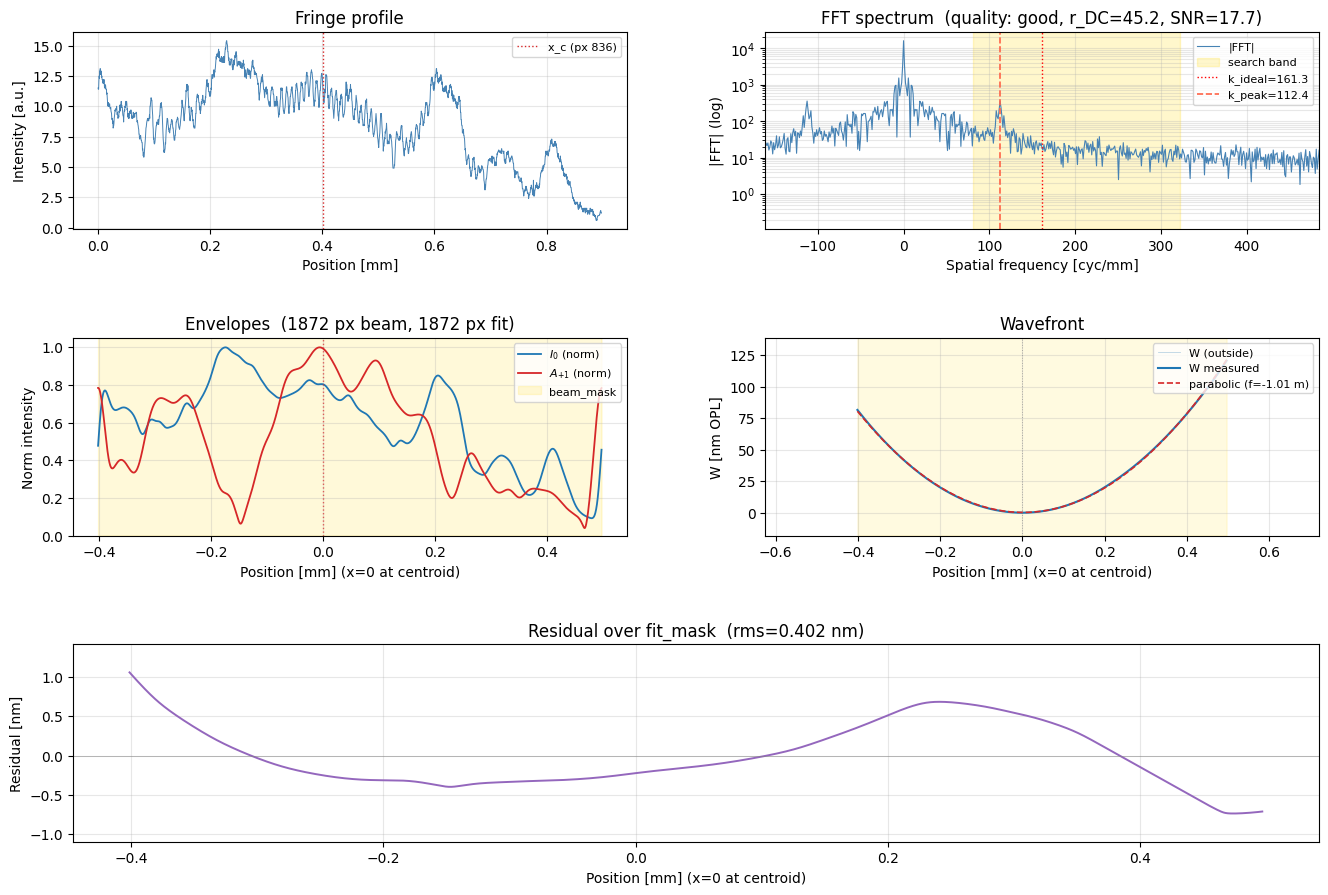

Exposure time: 5s
[good]  λ=0.15nm  k_peak=112.4 cyc/mm  r_DC=47.9  SNR=17.5  f_pred=-1.01m  RMS_W=32.5nm  RMS_resid=0.403nm


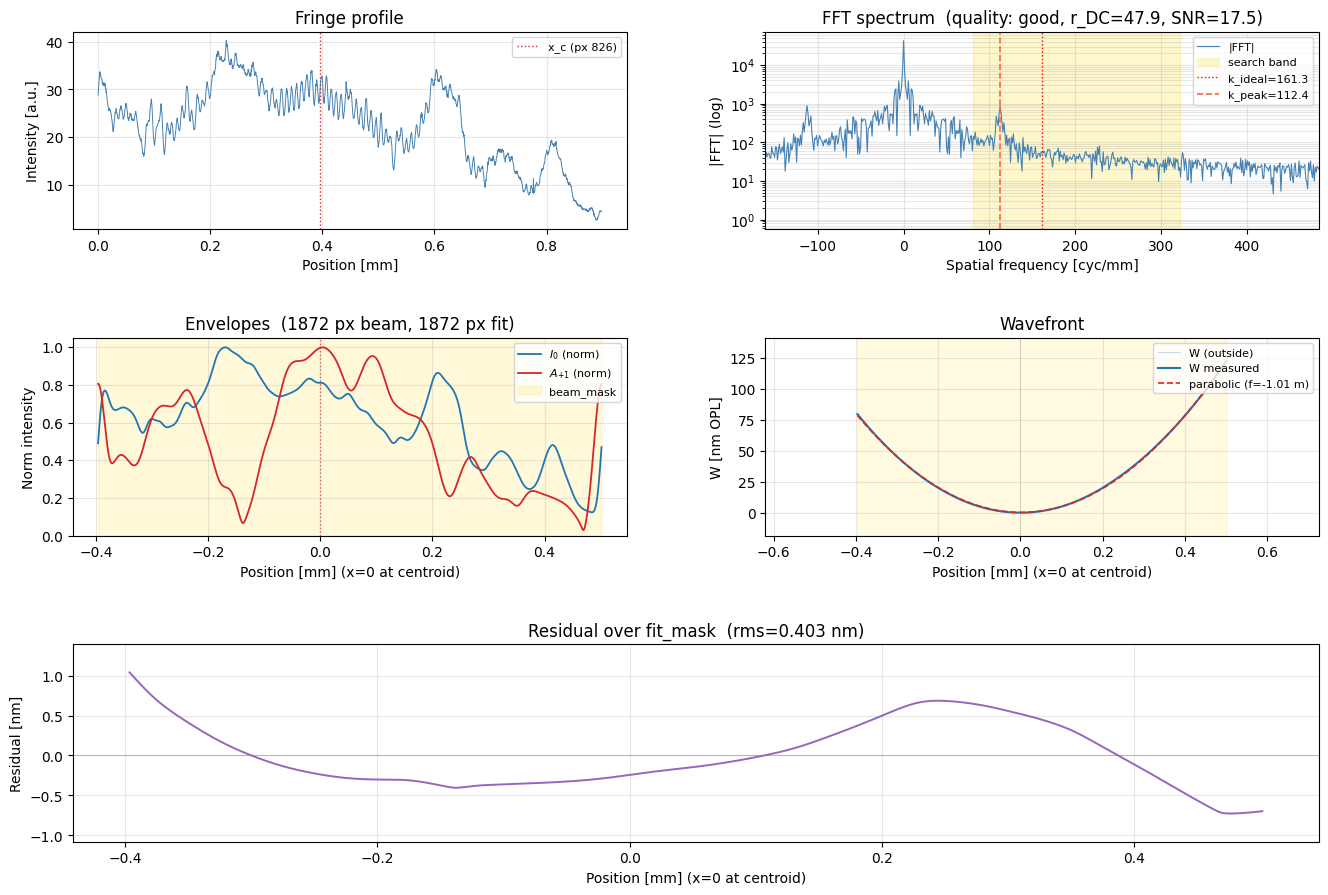

Exposure time: 10s
[good]  λ=0.15nm  k_peak=112.4 cyc/mm  r_DC=46.8  SNR=17.8  f_pred=-1.01m  RMS_W=32.6nm  RMS_resid=0.405nm


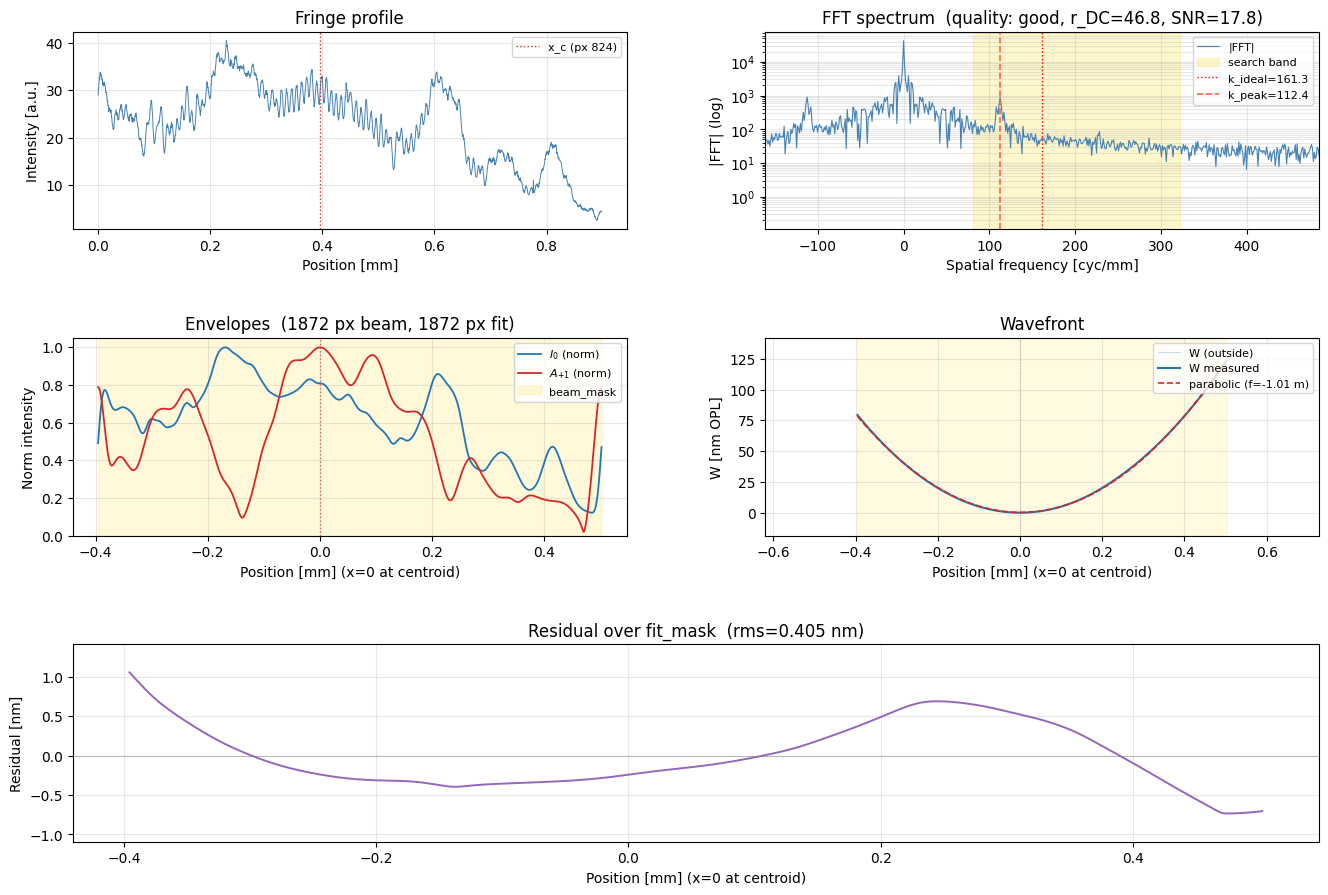

In [85]:
y_roi = slice(640+50, 650+50)

for exp_time in exposure_times:
    print(f"Exposure time: {exp_time}")
    _ = wfl.quick_look(
        images[exp_time][1800:], dx_m, grating_pitch_m, wavelength_m, z_gd_m, band_factor=2.0,
        y_roi=y_roi, axis=1, propagate=False, V_threshold=0
    )

## Relaxation after Applying Voltage

In [96]:
voltage_motor_AO0.set(10)

DeviceStatus(device=galil_voltage_AO0, done=True, success=True)

In [97]:
voltage_motor_AO0.set(0)

DeviceStatus(device=galil_voltage_AO0, done=True, success=True)

In [13]:
basler_5472.cam.stage_sigs['acquire_time']  = 1

In [14]:
voltage_motor_AO0.set(0)

DeviceStatus(device=galil_voltage_AO0, done=True, success=True)

In [23]:
import bluesky.plan_stubs as bps
from bluesky.plans import scan
from functools import partial

def per_step_multi_image(detectors, motor, step, num_images=10):
    # Move the motor to the target position
    yield from bps.mv(motor, step)

    # Trigger and read the detector(s) num_images times at this position
    for i in range(num_images):
        yield from bps.trigger_and_read(list(detectors) + [motor])

# Bind num_images so it matches the per_step(detectors, motor, step) signature
per_step = partial(per_step_multi_image, num_images=5)

uid = RE(scan([basler_5472], voltage_motor_AO0, 0, 10, 2, per_step=per_step))

In [24]:
print(uid)

('16e55048-b438-4506-b376-f524af402054',)


In [25]:
voltage_motor_AO0.set(0)

DeviceStatus(device=galil_voltage_AO0, done=True, success=True)

In [83]:
voltage_motor_AO0.set(0)
voltage_motor_AO1.set(0)
voltage_motor_AO2.set(0)
voltage_motor_AO3.set(0)
voltage_motor_AO4.set(0)
voltage_motor_AO5.set(0)
voltage_motor_AO6.set(0)
voltage_motor_AO7.set(0)
# RE = RunEngine({})

DeviceStatus(device=galil_voltage_AO7, done=True, success=True)

## Voltage Climbing for Each Channel

In [84]:
basler_5472.cam.stage_sigs['acquire_time']  = 10

In [88]:
import time
motors = [
    voltage_motor_AO0, voltage_motor_AO1, voltage_motor_AO2, voltage_motor_AO3,
    voltage_motor_AO4, voltage_motor_AO5, voltage_motor_AO6, voltage_motor_AO7,
]

uids = []
for m in motors:
    m.set(0)
time.sleep(30)

for motor in motors:
    # Reset all motors to 0 before scanning this one
    uid = RE(scan([basler_5472], motor, 0, 10, 11))
    uids.append(uid)
    print(f'{motor.name}: {uid}')
    motor.set(0)
    time.sleep(60)

# Leave everything at 0 when done
for m in motors:
    m.set(0)

galil_voltage_AO0: ('b36d1784-a686-4e8b-a4ed-8a0912868cc0',)
galil_voltage_AO1: ('8bed0754-e034-4666-bd6d-5387c9affc81',)
galil_voltage_AO2: ('141c83dc-9b1f-4a8e-81dd-ca74df154178',)
galil_voltage_AO3: ('43d0f82b-0f59-4471-99e2-126da577509d',)
galil_voltage_AO4: ('2912dc2b-7a00-4737-b4a0-229e6fbe3078',)
galil_voltage_AO5: ('b88bfc05-7e0e-45de-bd9d-4f1878c5e758',)
galil_voltage_AO6: ('ac451378-3020-47c7-a7be-490a52e12a2e',)
galil_voltage_AO7: ('7f6a1412-6fdc-4e4a-b117-0b2fd08d9873',)


In [89]:
uids

[('b36d1784-a686-4e8b-a4ed-8a0912868cc0',),
 ('8bed0754-e034-4666-bd6d-5387c9affc81',),
 ('141c83dc-9b1f-4a8e-81dd-ca74df154178',),
 ('43d0f82b-0f59-4471-99e2-126da577509d',),
 ('2912dc2b-7a00-4737-b4a0-229e6fbe3078',),
 ('b88bfc05-7e0e-45de-bd9d-4f1878c5e758',),
 ('ac451378-3020-47c7-a7be-490a52e12a2e',),
 ('7f6a1412-6fdc-4e4a-b117-0b2fd08d9873',)]

## scan all the channels together

In [8]:
import operator
from functools import reduce

class GangedVoltageMotor:
    """Pseudo-motor that moves several voltage motors to the same setpoint simultaneously."""

    def __init__(self, motors, name='ganged_voltage'):
        self._motors = motors
        self.name = name
        self.parent = None

    def set(self, value):
        statuses = [m.set(value) for m in self._motors]
        combined_status = reduce(operator.and_, statuses)
        return combined_status

    def stop(self, success=False):
        for m in self._motors:
            m.stop(success=success)

    @property
    def position(self):
        return self._motors[0].position

    def read(self):
        d = {}
        for m in self._motors:
            d.update(m.read())
        return d

    def describe(self):
        d = {}
        for m in self._motors:
            d.update(m.describe())
        return d

    def read_configuration(self):
        return {}

    def describe_configuration(self):
        return {}

    @property
    def hints(self):
        return {'fields': [self._motors[0].name]}

In [92]:
motors = [
    voltage_motor_AO0, voltage_motor_AO1, voltage_motor_AO2, voltage_motor_AO3,
    voltage_motor_AO4, voltage_motor_AO5, voltage_motor_AO6, voltage_motor_AO7,
]

ganged = GangedVoltageMotor(motors, name='ganged_voltage')

uid = RE(scan([basler_5472], ganged, 0, 10, 21))

In [100]:
print(uid)

('b427e05b-13c3-46c0-b573-59468f227717',)


## Creep Estimate for Motors, Ganged

In [14]:
basler_5472.cam.stage_sigs['acquire_time']  = 1

In [12]:
voltage_motor_AO7.get()

GalilVoltageMotorTuple(readback=0.0)

In [13]:
motors = [
    voltage_motor_AO0, voltage_motor_AO1, voltage_motor_AO2, voltage_motor_AO3,
    voltage_motor_AO4, voltage_motor_AO5, voltage_motor_AO6, voltage_motor_AO7,
]

ganged = GangedVoltageMotor(motors, name='ganged_voltage')

In [15]:
from bluesky.plans import count

ganged.set(10)

print('start scan')

uid = RE(count([basler_5472], num=600))
print(uid)

ganged.set(0)


start scan


Transient Scan ID: 1     Time: 2026-07-02 14:59:10
Persistent Unique Scan ID: 'b56ad6dd-1ba8-4fe0-a8f1-9df01db9af99'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|              mono_angle_offset | 6.597347761216428              |
|                          diode | -0.1653                        |
|          mono_energy_energy_eV | 8089.634247877096              |
|         mono_energy_mono_angle | 20.746                         |
|                     sampleJack | 25.0                           |
|         gi_angle_grazing_angle | -0.21499836230621183           |
|   gi_angle_hexapod_ry_readback | -0.21499836230621183           |
|      hexapod_motor_Tx_readback | 0.0003947127533804884          |
|      hexapod_motor_Ty_readback | -3.5399851060423635            |
|      hexapod_motor_Tz_readback | -2.8199986883867183            |
|      hexapod_motor_Rx_readback | -0.00012148906781653467        |

(((((((DeviceStatus(device=galil_voltage_AO0, done=True, success=True) & DeviceStatus(device=galil_voltage_AO1, done=True, success=True)) & DeviceStatus(device=galil_voltage_AO2, done=True, success=True)) & DeviceStatus(device=galil_voltage_AO3, done=True, success=True)) & DeviceStatus(device=galil_voltage_AO4, done=True, success=True)) & DeviceStatus(device=galil_voltage_AO5, done=True, success=True)) & DeviceStatus(device=galil_voltage_AO6, done=True, success=True)) & DeviceStatus(device=galil_voltage_AO7, done=True, success=True))

## scan on one channel back and forth 0V ~ 10V 50 times with 10s exposure time

In [ ]:
basler_5472.cam.stage_sigs['acquire_time']  = 1

In [9]:
import bluesky.plan_stubs as bps
from bluesky.plans import list_scan
from functools import partial

def per_step_multi_image(detectors, motor, step, num_images=5):
    yield from bps.mv(motor, step)
    for i in range(num_images):
        yield from bps.trigger_and_read(list(detectors) + [motor])

per_step = partial(per_step_multi_image, num_images=2)

n_cycles = 5
points = [0, 10] * n_cycles   # 0, 10, 0, 10, ... alternating, 100 points total

uid = RE(list_scan([basler_5472], voltage_motor_AO4, points, per_step=per_step))



Transient Scan ID: 1     Time: 2026-07-02 15:43:55
Persistent Unique Scan ID: '4ebcb929-8da3-4a6e-a5e7-4d10709dba5d'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|              mono_angle_offset | 6.597347761216428              |
|                          diode | -0.1811                        |
|          mono_energy_energy_eV | 8089.634247877096              |
|         mono_energy_mono_angle | 20.746                         |
|                     sampleJack | 25.0                           |
|         gi_angle_grazing_angle | -0.21499567120495688           |
|   gi_angle_hexapod_ry_readback | -0.21499567120495688           |
|      hexapod_motor_Tx_readback | 0.0003914063862285322          |
|      hexapod_motor_Ty_readback | -3.539990562539806             |
|      hexapod_motor_Tz_readback | -2.8199996985713796            |
|      hexapod_motor_Rx_readback | -0.00011871216048312527        |
|      hex

In [10]:
basler_5472.cam.stage_sigs['acquire_time']  = 10

In [11]:
import bluesky.plan_stubs as bps
from bluesky.plans import list_scan
from functools import partial

def per_step_multi_image(detectors, motor, step, num_images=5):
    yield from bps.mv(motor, step)
    for i in range(num_images):
        yield from bps.trigger_and_read(list(detectors) + [motor])

per_step = partial(per_step_multi_image, num_images=2)

n_cycles = 5
points = [0, 10] * n_cycles   # 0, 10, 0, 10, ... alternating, 100 points total

uid = RE(list_scan([basler_5472], voltage_motor_AO4, points, per_step=per_step))



Transient Scan ID: 2     Time: 2026-07-02 15:44:41
Persistent Unique Scan ID: '9374443d-97bb-47eb-b30d-d6a1accfcd4d'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|              mono_angle_offset | 6.597347761216428              |
|                          diode | -0.1785                        |
|          mono_energy_energy_eV | 8089.634247877096              |
|         mono_energy_mono_angle | 20.746                         |
|                     sampleJack | 25.0                           |
|         gi_angle_grazing_angle | -0.21500190008517428           |
|   gi_angle_hexapod_ry_readback | -0.21500190008517428           |
|      hexapod_motor_Tx_readback | 0.0003936428467908315          |
|      hexapod_motor_Ty_readback | -3.54000280473701              |
|      hexapod_motor_Tz_readback | -2.8199997352904376            |
|      hexapod_motor_Rx_readback | -0.00011664193352163327        |
|      hex

## random voltages on each channel

In [12]:
import numpy as np
from bluesky.plans import list_scan
import bluesky.plan_stubs as bps
from functools import partial

motors = [
    voltage_motor_AO0, voltage_motor_AO1, voltage_motor_AO2, voltage_motor_AO3,
    voltage_motor_AO4, voltage_motor_AO5, voltage_motor_AO6, voltage_motor_AO7,
]

num_points = 5
rng = np.random.default_rng(seed=42)

# Precompute independent random voltage sequences for each motor
voltage_lists = [rng.uniform(0, 10, size=num_points).tolist() for _ in motors]

def per_step_multi_image(detectors, step, pos_cache, num_images=1):
    # step is a dict {motor: target_position, ...} for list_scan with multiple motors
    motors_ = list(step.keys())
    yield from bps.mv(*[x for m in motors_ for x in (m, step[m])])
    for _ in range(num_images):
        yield from bps.trigger_and_read(list(detectors) + motors_)

per_step = partial(per_step_multi_image, num_images=1)

# Interleave motor/list pairs: motor1, list1, motor2, list2, ...
args = []
for m, vlist in zip(motors, voltage_lists):
    args.extend([m, vlist])

uid = RE(list_scan([basler_5472], *args, per_step=per_step))



Transient Scan ID: 3     Time: 2026-07-02 15:48:48
Persistent Unique Scan ID: '61c5d2ec-41c4-47f9-aa67-58cc648a1e57'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|              mono_angle_offset | 6.597347761216428              |
|                          diode | -0.1808                        |
|          mono_energy_energy_eV | 8089.634247877096              |
|         mono_energy_mono_angle | 20.746                         |
|                     sampleJack | 25.0                           |
|         gi_angle_grazing_angle | -0.21499941422450114           |
|   gi_angle_hexapod_ry_readback | -0.21499941422450114           |
|      hexapod_motor_Tx_readback | 0.0004079940604520549          |
|      hexapod_motor_Ty_readback | -3.5399917978468523            |
|      hexapod_motor_Tz_readback | -2.819998676696713             |
|      hexapod_motor_Rx_readback | -0.00012227824480126912        |
|      hex

In [14]:
Obender.get()

EpicsMotorTuple(user_readback=-800.01486, user_setpoint=-800.0, user_offset=0.0, user_offset_dir=0, offset_freeze_switch=0, set_use_switch=0, velocity=100.0, acceleration=0.2, motor_egu='um', motor_is_moving=0, motor_done_move=1, high_limit_switch=0, low_limit_switch=0, high_limit_travel=5000.0, low_limit_travel=-2000.0, direction_of_travel=1, motor_stop=0, home_forward=0, home_reverse=0)

In [15]:
import numpy as np
from bluesky.plans import list_scan
import bluesky.plan_stubs as bps
from functools import partial

motors = [
    voltage_motor_AO0, voltage_motor_AO1, voltage_motor_AO2, voltage_motor_AO3,
    voltage_motor_AO4, voltage_motor_AO5, voltage_motor_AO6, voltage_motor_AO7,
]

num_points = 1500
rng = np.random.default_rng(seed=42)

# Precompute independent random voltage sequences for each motor
voltage_lists = [rng.uniform(0, 10, size=num_points).tolist() for _ in motors]

def per_step_multi_image(detectors, step, pos_cache, num_images=1):
    # step is a dict {motor: target_position, ...} for list_scan with multiple motors
    motors_ = list(step.keys())
    yield from bps.mv(*[x for m in motors_ for x in (m, step[m])])
    for _ in range(num_images):
        yield from bps.trigger_and_read(list(detectors) + motors_)

per_step = partial(per_step_multi_image, num_images=1)

# Interleave motor/list pairs: motor1, list1, motor2, list2, ...
args = []
for m, vlist in zip(motors, voltage_lists):
    args.extend([m, vlist])

uid = RE(list_scan([basler_5472], *args, per_step=per_step))



Transient Scan ID: 4     Time: 2026-07-02 15:53:20
Persistent Unique Scan ID: 'a304a337-20aa-444c-af6c-deb1acc17e3a'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|              mono_angle_offset | 6.597347761216428              |
|                          diode | -0.1871                        |
|          mono_energy_energy_eV | 8089.634247877096              |
|         mono_energy_mono_angle | 20.746                         |
|                     sampleJack | 25.0                           |
|         gi_angle_grazing_angle | -0.21500458776251355           |
|   gi_angle_hexapod_ry_readback | -0.21500458776251355           |
|      hexapod_motor_Tx_readback | 0.0003978825946795439          |
|      hexapod_motor_Ty_readback | -3.5399974878475904            |
|      hexapod_motor_Tz_readback | -2.8199984461142122            |
|      hexapod_motor_Rx_readback | -0.00011942248880729282        |
|      hex

# LIVE ANALYSIS - tweaking measurement parameters

In [26]:
db = tiled_client[uid]['primary']

images_flat = db['basler_5472_image'].read()
voltage_flat = db['galil_voltage_AO0_readback'].read()

num_images_per_step = 5
num_steps = len(voltage_flat) // num_images_per_step

images = np.asarray(images_flat).reshape(num_steps, num_images_per_step, *np.asarray(images_flat).shape[1:])
voltage = np.asarray(voltage_flat).reshape(num_steps, num_images_per_step)
voltage_per_step = voltage.mean(axis=1)
print("Voltage steps:", voltage_per_step)


Voltage steps: [2.e-04 1.e+01]


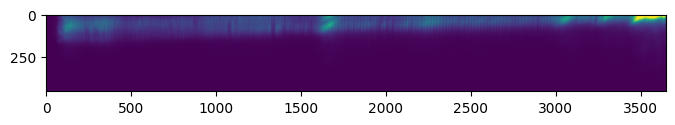

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(8, 6))
plt.imshow(images[0,4].T[350:])

[  ok]  λ=0.15nm  k_peak=112.7 cyc/mm  r_DC=74.8  SNR=7.3  f_pred=-1.01m  RMS_W=35.3nm  RMS_resid=0.135nm


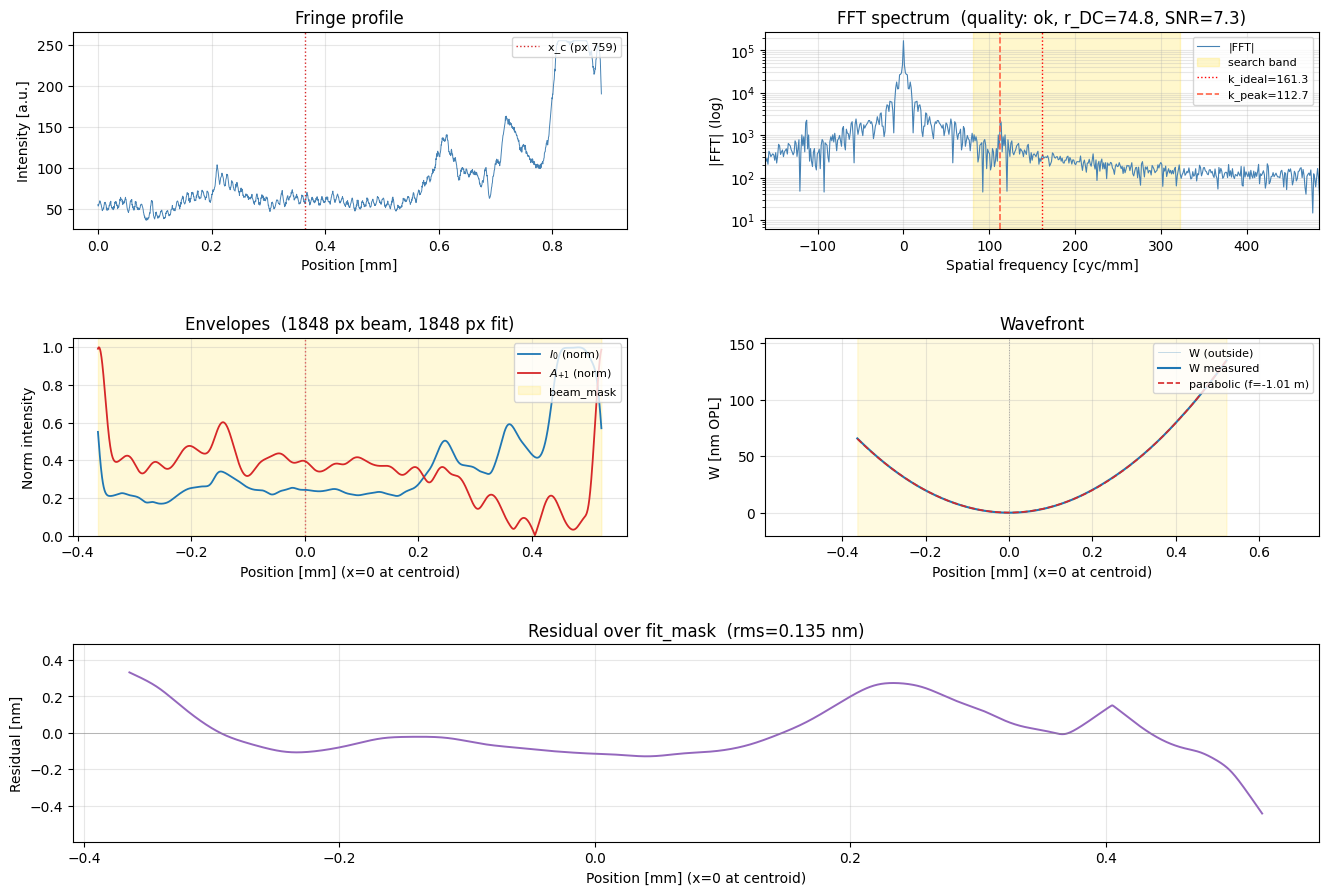

In [ ]:
y_roi = slice(350, 370)

r_quick_0 = wfl.quick_look(
    images[0, 0][1800:], dx_m, grating_pitch_m, wavelength_m, z_gd_m, band_factor=2,
    y_roi=y_roi, axis=1, propagate=False, V_threshold=0
)


[  ok]  λ=0.15nm  k_peak=112.7 cyc/mm  r_DC=56.6  SNR=6.5  f_pred=-0.99m  RMS_W=34.0nm  RMS_resid=0.273nm


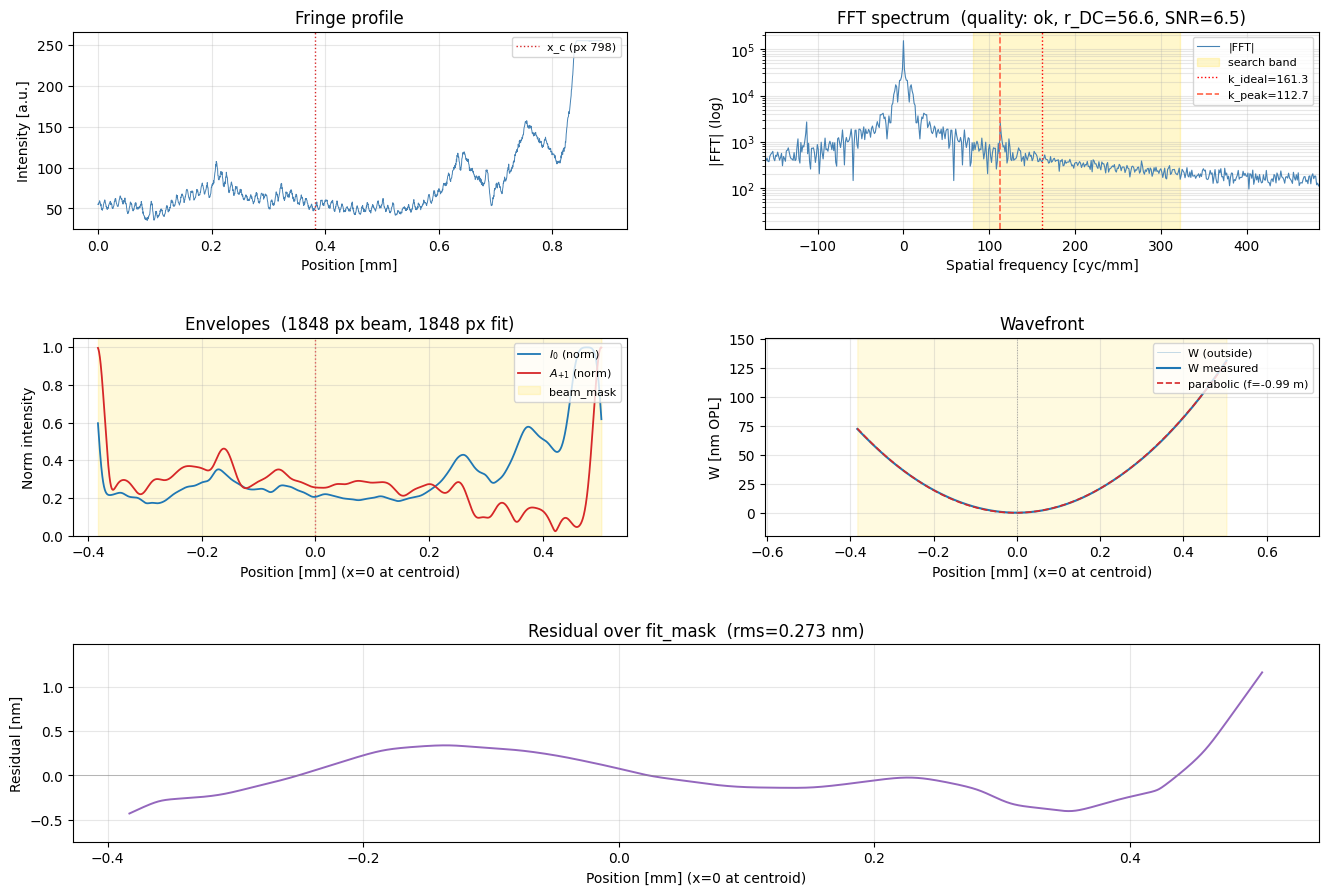

In [51]:
y_roi = slice(350, 370)

r_quick_0 = wfl.quick_look(
    images[1, 0][1800:], dx_m, grating_pitch_m, wavelength_m, z_gd_m, band_factor=2,
    y_roi=y_roi, axis=1, propagate=False, V_threshold=0
)


In [ ]:
y_roi = slice(350, 370)

# Reference x_c from position 0, repeat 0
r_quick_0 = wfl.reconstruct_single(
    images[0, 0][1800:], dx_m, grating_pitch_m, wavelength_m, z_gd_m, band_factor=1.8,
    y_roi=y_roi, axis=1, propagate=False, V_threshold=0
)
x_c_ref = r_quick_0['x_c']
print(x_c_ref)

wfs_0V = []
for j in range(5):
    r_quick = wfl.reconstruct_single(
        images[0, j][1800:], dx_m, grating_pitch_m, wavelength_m, z_gd_m, band_factor=1.8,
        x_c_override=x_c_ref,   # Change this to overide 
        y_roi=y_roi, axis=1, propagate=False, V_threshold=0
    )
    wfs_0V.append(r_quick)

759


In [53]:
y_roi = slice(350, 370)

# Reference x_c from position 0, repeat 0
r_quick_0 = wfl.reconstruct_single(
    images[0, 0][1800:], dx_m, grating_pitch_m, wavelength_m, z_gd_m, band_factor=1.8,
    y_roi=y_roi, axis=1, propagate=False, V_threshold=0
)
x_c_ref = r_quick_0['x_c']
print(x_c_ref)

wfs_10V = []
for j in range(5):
    r_quick = wfl.reconstruct_single(
        images[1, j][1800:], dx_m, grating_pitch_m, wavelength_m, z_gd_m, band_factor=1.8,
        x_c_override=x_c_ref,   # Change this to overide 
        y_roi=y_roi, axis=1, propagate=False, V_threshold=0
    )
    wfs_10V.append(r_quick)

759


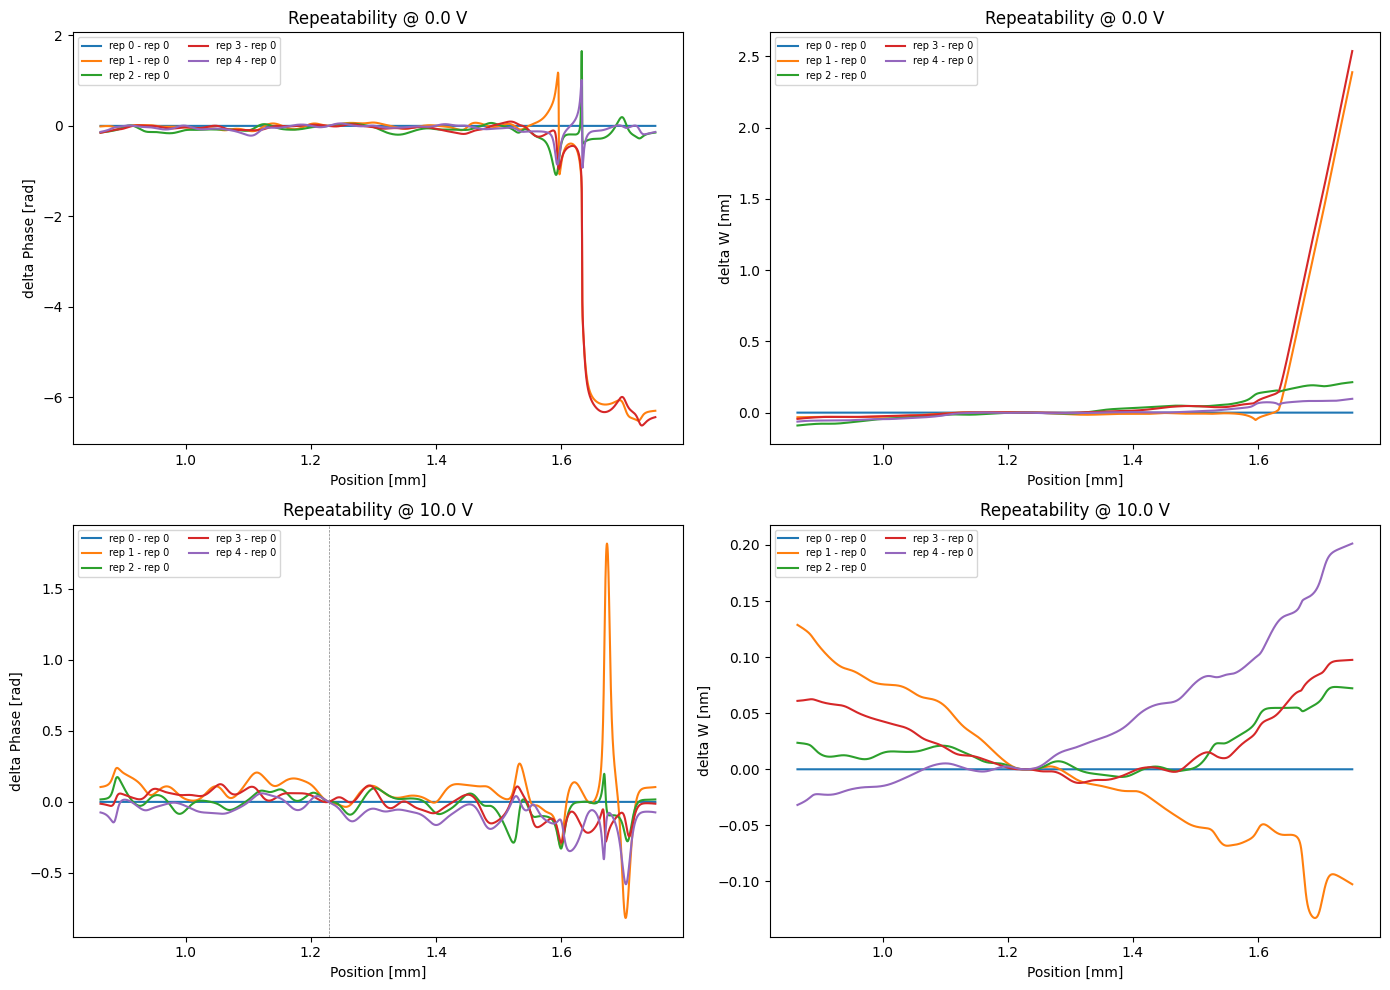

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 0V: delta_phi ---
for j in range(len(wfs_0V)):
    delta_phi_jj = wfs_0V[j]['delta_phi'] - wfs_0V[0]['delta_phi']
    axes[0, 0].plot(x_m[1800:]*1e3, delta_phi_jj, label=f'rep {j} - rep 0')
axes[0, 0].set_xlabel('Position [mm]')
axes[0, 0].set_ylabel('delta Phase [rad]')
axes[0, 0].set_title(f'Drifting @ {voltage[0, 0]:.1f} V')
axes[0, 0].legend(fontsize=7, ncol=2)

# --- 0V: delta_W ---
for j in range(len(wfs_0V)):
    delta_W_jj = wfs_0V[j]['W_nm'] - wfs_0V[0]['W_nm']
    axes[0, 1].plot(x_m[1800:]*1e3, delta_W_jj, label=f'rep {j} - rep 0')
axes[0, 1].set_xlabel('Position [mm]')
axes[0, 1].set_ylabel('delta W [nm]')
axes[0, 1].set_title(f'Drifting @ {voltage[0, 0]:.1f} V')
axes[0, 1].legend(fontsize=7, ncol=2)

# --- 10V: delta_phi ---
for j in range(len(wfs_10V)):
    delta_phi_jj = wfs_10V[j]['delta_phi'] - wfs_10V[0]['delta_phi']
    axes[1, 0].plot(x_m[1800:]*1e3, delta_phi_jj, label=f'rep {j} - rep 0')
axes[1, 0].set_xlabel('Position [mm]')
axes[1, 0].set_ylabel('delta Phase [rad]')
axes[1, 0].set_title(f'Drifting @ {voltage[1, 0]:.1f} V')
axes[1, 0].axvline(x_c_ref*dx_m*1e3+x_m[1800]*1e3, color='gray', linestyle='--', linewidth=0.5)
axes[1, 0].legend(fontsize=7, ncol=2)

# --- 10V: delta_W ---
for j in range(len(wfs_10V)):
    delta_W_jj = wfs_10V[j]['W_nm'] - wfs_10V[0]['W_nm']
    axes[1, 1].plot(x_m[1800:]*1e3, delta_W_jj, label=f'rep {j} - rep 0')
axes[1, 1].set_xlabel('Position [mm]')
axes[1, 1].set_ylabel('delta W [nm]')
axes[1, 1].set_title(f'Drifting @ {voltage[1, 0]:.1f} V')
axes[1, 1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

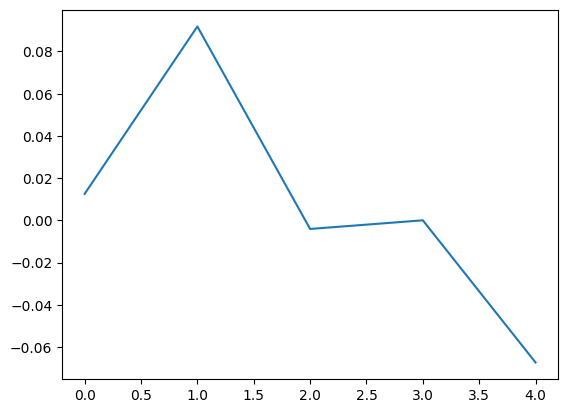

In [72]:
delta_phi_10V = []
for j in range(len(wfs_10V)):
    delta_phi_10V.append(wfs_10V[j]['delta_phi'] - wfs_10V[3]['delta_phi'])

delta_phi_10V_avg = np.mean(delta_phi_10V, axis=1)    

plt.plot(delta_phi_10V_avg)